First, I installed the WordCloud package, and generated a word cloud from a sample string. 

Note: you may need to restart the kernel to use updated packages.


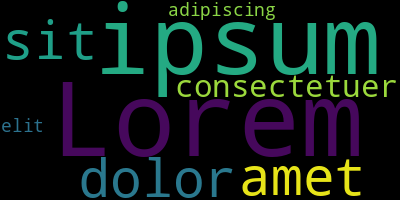

In [ ]:
%pip install wordcloud
from wordcloud import WordCloud

wc = WordCloud().generate("Lorem ipsum dolor sit amet consectetuer adipiscing elit")
img = wc.to_image()
img.show()

After that, I retrieved a text file from a Google Drive URL, and displayed the first part of it.

In [ ]:
import urllib.request

text = urllib.request.urlopen("https://drive.google.com/uc?export=download&id=1gNDt93QaPa73a4OQhpEieofD4KTUw0B9").read().decode("utf-8")
text[:131]

'A wonderful serenity has taken possession of my entire soul, like these sweet mornings of spring which I enjoy with my whole heart.'

Using the downloaded text, I generated an image (word cloud).

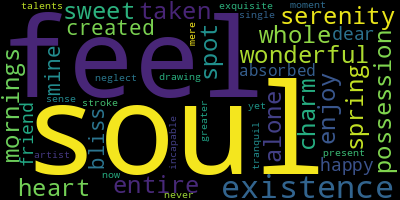

In [33]:
WordCloud().generate_from_text(text).to_image()

Here, I generated a word cloud from the text, while also marking which words should be omitted (stopwords). I displayed it with a white background.

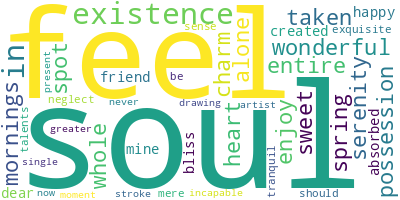

In [79]:
WordCloud(stopwords = ["of", "my", "like", "was", "so", "and", "I", "a", "the", "with", "am", "which", "that", "at", "than", "yet", "has", "this", "these", "for"],
background_color = "white").generate_from_text(text).to_image()

I imported an image from a Google Drive URL.

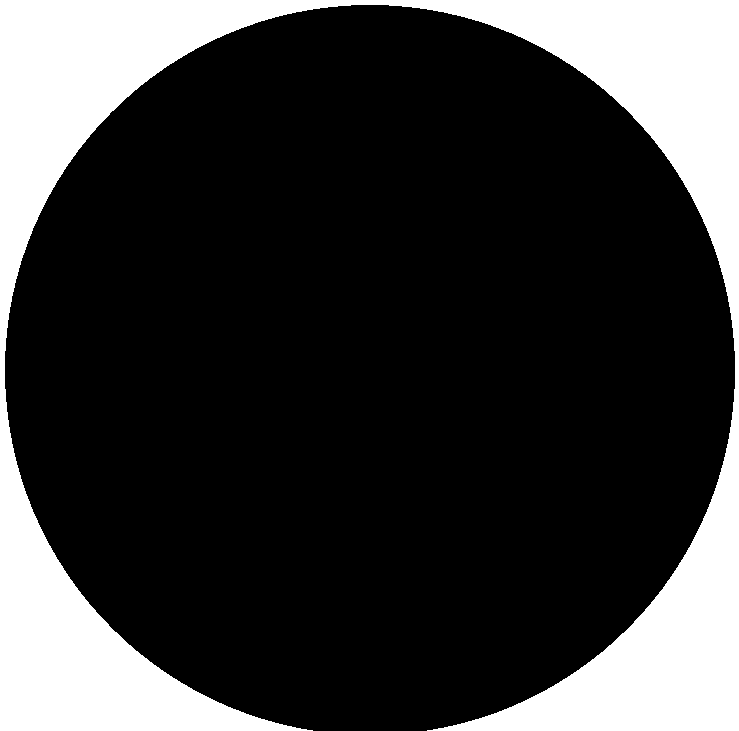

In [ ]:
from PIL import Image
import urllib.request

img = urllib.request.urlretrieve("https://drive.google.com/uc?export=download&id=1Z_tgupVbtR1PbNiB4IpNeoZkC6JsslYp", "image1.png")
Image.open("image1.png")

Combining the imported text and image, I created a circular word cloud.

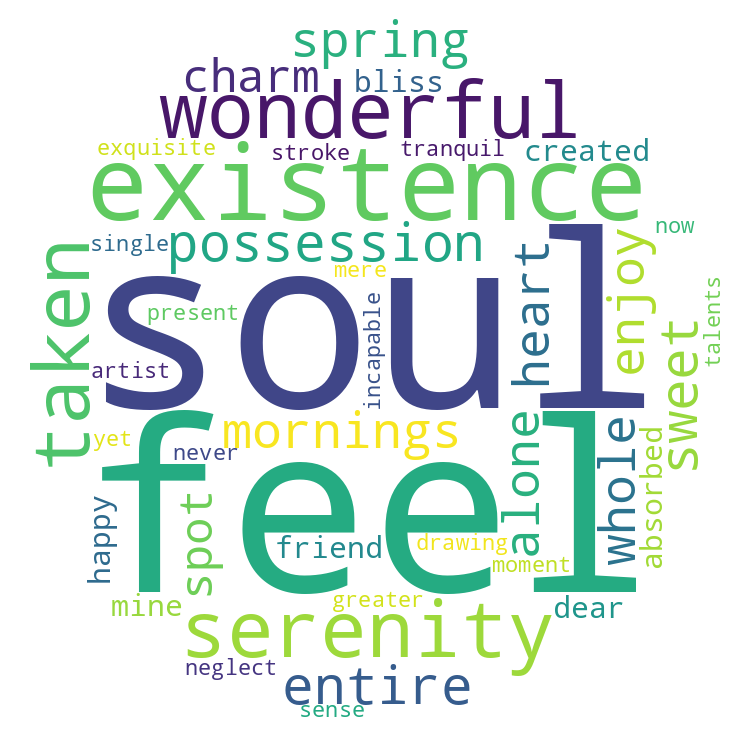

In [49]:
import urllib.request
from PIL import Image
import numpy as np

text = urllib.request.urlopen("https://drive.google.com/uc?export=download&id=1gNDt93QaPa73a4OQhpEieofD4KTUw0B9").read().decode("utf-8")
img = urllib.request.urlretrieve("https://drive.google.com/uc?export=download&id=1Z_tgupVbtR1PbNiB4IpNeoZkC6JsslYp", "image1.png")
WordCloud(mask = np.array(Image.open("image1.png")), background_color = "white").generate_from_text(text).to_image()

Generating another circular word cloud, this time I defined a function that chose colors based on word length. The original text is about being in the moment and finding happiness during those points of time. Therefore, this word cloud emphasizes the joy of living and experiencing, with words like "soul," "feel," and "serenity" being highlighted. The colors I chose represent feelings of contentment (in my opinion).

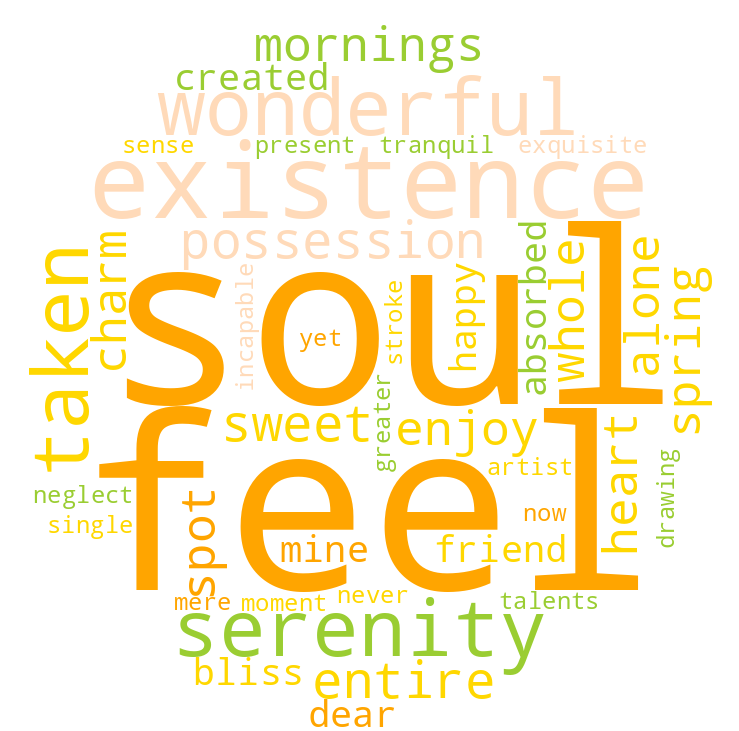

In [80]:
def color_function(word, font_size, position, orientation, random_state = None, font_path = None):
    if len(word) < 5:
        return "orange"
    elif len(word) < 7:
        return "gold"
    elif len(word) < 9:
        return "yellowgreen"
    else:
        return "peachpuff"
WordCloud(mask = np.array(Image.open("image1.png")), background_color = "white").generate_from_text(text).recolor(color_func = color_function).to_image()